# VAE on MNIST

A follow-up to [`03_vae.ipynb`](03_vae.ipynb), which demonstrated VAE *plumbing* on random noise. Here we apply the same architecture to **MNIST** — a structured dataset with real learnable signal — so you can watch the reconstruction loss actually decrease and visually inspect what the latent space has learned.

Inspired by: https://towardsdatascience.com/uncovering-anomalies-with-variational-autoencoders-vae-a-deep-dive-into-the-world-of-1b2bce47e2e9/


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DL4DS/sp2026/blob/main/lecture_collateral/vae/04_vae_mnist.ipynb)

## What to watch for

In the random-noise notebook, the reconstruction loss stayed pinned at `≈ ln 2 ≈ 0.693` (chance-level BCE) because there was nothing to learn — only the KL term decreased, as the encoder collapsed toward the prior `N(0, I)`.

Here, on MNIST, you should see something very different:

1. **Reconstruction loss drops substantially** — the decoder is actually learning to reproduce digit pixels from the latent code.
2. **KL loss stays non-trivial** — the encoder must deviate from the prior to carry enough information about each digit; it trades off against reconstruction rather than collapsing.
3. **Reconstructed digits look like the inputs** — visibly blurrier than the originals (a well-known VAE artifact of the Gaussian latent + pixel-wise BCE), but recognizable.
4. **Samples from the prior `N(0, I)`** decoded through the trained decoder should look like plausible, if imperfect, digits — evidence the latent space is *smooth* and *generative*, not just a lookup table.

### A note on the loss

We use `BCELoss(reduction='sum')` on the pixels plus the analytic KL term, **both summed per sample and then averaged over the batch**. This keeps the two terms on comparable scales — important because using `reduction='mean'` for BCE (as in the random-data notebook) makes the KL term dominate by a factor of ~784 and leads to posterior collapse.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


## VAE Architecture

Same structure as the random-input notebook, but with widths appropriate for 28×28 = 784-pixel MNIST images and a larger latent dimension (20). The encoder outputs the mean and log-variance of the approximate posterior `q(z|x)`; the reparameterization trick lets gradients flow through the stochastic sampling step.

In [2]:
# Define the VAE model
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )
        # Latent heads
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),
        )

    def forward(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        reconstructed = self.decoder(z)
        return reconstructed, mu, logvar

    def reparameterize(self, mu, logvar):
        std = logvar.mul(0.5).exp_()
        eps = torch.randn_like(std)
        return mu + std * eps

In [3]:
# Load MNIST
transform = transforms.ToTensor()  # scales pixels to [0, 1] — needed for BCE + Sigmoid
train_set = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_set  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_set, batch_size=batch_size, shuffle=False)

print(f"Train samples: {len(train_set)}, Test samples: {len(test_set)}")

Train samples: 60000, Test samples: 10000


## Training

The ELBO loss is `reconstruction_loss + kl_loss`, both summed over dimensions within a sample and averaged over the batch. Watch the reconstruction term — unlike the random-noise case, it should drop steadily as the model learns digit structure.

In [4]:
# Instantiate the model
model = VAE(input_dim=784, hidden_dim=400, latent_dim=20).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Sum over pixels; we'll divide by batch size so recon and KL are on the same scale.
bce = nn.BCELoss(reduction="sum")

def vae_loss(reconstructed, x, mu, logvar):
    recon = bce(reconstructed, x)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon, kl

In [5]:
# Train the model
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_recon, running_kl, running_n = 0.0, 0.0, 0

    for x, _ in train_loader:
        x = x.view(x.size(0), -1).to(device)  # flatten 28x28 -> 784

        reconstructed, mu, logvar = model(x)
        recon, kl = vae_loss(reconstructed, x, mu, logvar)
        loss = (recon + kl) / x.size(0)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_recon += recon.item()
        running_kl    += kl.item()
        running_n     += x.size(0)

    avg_recon = running_recon / running_n
    avg_kl    = running_kl / running_n
    print(f"Epoch {epoch:02d}: recon = {avg_recon:.2f}, kl = {avg_kl:.2f}, total = {avg_recon + avg_kl:.2f}")

Epoch 00: recon = 149.08, kl = 15.46, total = 164.53
Epoch 01: recon = 99.36, kl = 22.23, total = 121.58
Epoch 02: recon = 90.85, kl = 23.79, total = 114.64
Epoch 03: recon = 87.27, kl = 24.37, total = 111.64
Epoch 04: recon = 85.20, kl = 24.74, total = 109.94
Epoch 05: recon = 83.82, kl = 24.93, total = 108.75
Epoch 06: recon = 82.85, kl = 25.05, total = 107.90
Epoch 07: recon = 82.15, kl = 25.17, total = 107.31
Epoch 08: recon = 81.53, kl = 25.21, total = 106.74
Epoch 09: recon = 81.06, kl = 25.25, total = 106.31


## Visualize Reconstructions

Compare held-out test inputs (top row) to what the VAE reconstructs through its latent bottleneck (bottom row). Expect recognizable but slightly blurry digits — the blur is characteristic of pixel-wise Gaussian/Bernoulli VAEs.

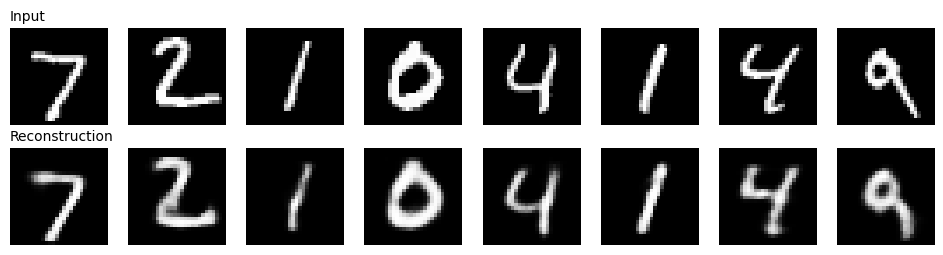

In [6]:
model.eval()
with torch.no_grad():
    x, _ = next(iter(test_loader))
    x_flat = x.view(x.size(0), -1).to(device)
    reconstructed, _, _ = model(x_flat)
    reconstructed = reconstructed.view(-1, 28, 28).cpu()

n = 8
fig, axes = plt.subplots(2, n, figsize=(n * 1.2, 2.6))
for i in range(n):
    axes[0, i].imshow(x[i, 0], cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(reconstructed[i], cmap="gray"); axes[1, i].axis("off")
axes[0, 0].set_title("Input",        loc="left", fontsize=10)
axes[1, 0].set_title("Reconstruction", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## Sample from the Prior

A VAE is a *generative* model: if training worked, decoding random draws from `z ~ N(0, I)` should produce plausible digits the network has never seen. This is what distinguishes a VAE from a plain autoencoder — the KL term forces the latent space to be dense and smooth, so *any* point near the origin decodes to something digit-like.

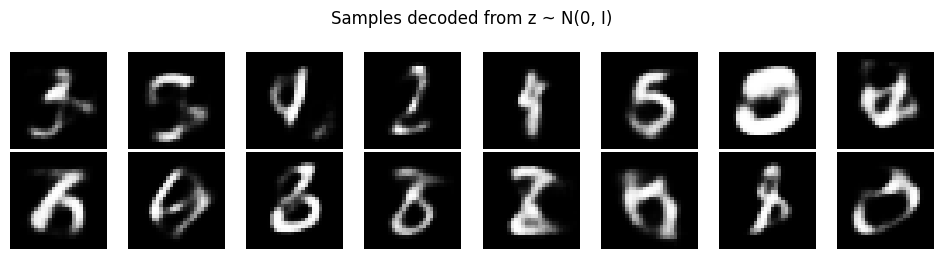

In [19]:
model.eval()
with torch.no_grad():
    z = torch.randn(16, 20, device=device)  # 16 samples from N(0, I)
    samples = model.decoder(z).view(-1, 28, 28).cpu()

fig, axes = plt.subplots(2, 8, figsize=(8 * 1.2, 2.6))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i], cmap="gray"); ax.axis("off")
plt.suptitle("Samples decoded from z ~ N(0, I)")
plt.tight_layout(); plt.show()